Importación de librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Carga del dataset

In [2]:
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/mpg.csv"
df = pd.read_csv(url)

Exploración de datos

In [3]:
# Primeras 5 filas
df.head()
# Información general del dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    object 
 8   name          398 non-null    object 
dtypes: float64(4), int64(3), object(2)
memory usage: 28.1+ KB


Limpieza de datos

In [4]:
# Ver valores nulos en horsepower
df['horsepower'].isnull().sum()
# Reemplazar valores nulos con la mediana
mediana = np.nanmedian(df['horsepower'])
df['horsepower'].fillna(mediana, inplace=True)
# Verificar que ya no hay nulos
df['horsepower'].isnull().sum()

/tmp/ipykernel_1082/1715551619.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['horsepower'].fillna(mediana, inplace=True)


np.int64(0)

Nueva columna

In [5]:
df['relacion_peso_potencia'] = df['weight'] / df['horsepower']

# Mostrar resultados
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name,relacion_peso_potencia
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu,26.953846
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320,22.381818
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite,22.906667
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst,22.886667
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino,24.635714


Histograma (acceleration)

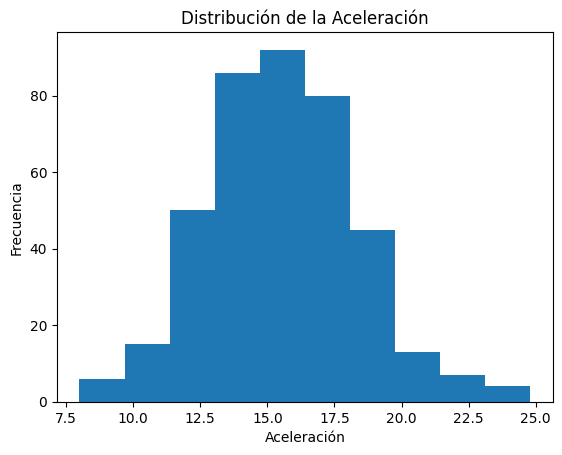

In [6]:
plt.figure()
plt.hist(df['acceleration'])
plt.title("Distribución de la Aceleración")
plt.xlabel("Aceleración")
plt.ylabel("Frecuencia")
plt.show()

Gráfico de dispersión (scatter)

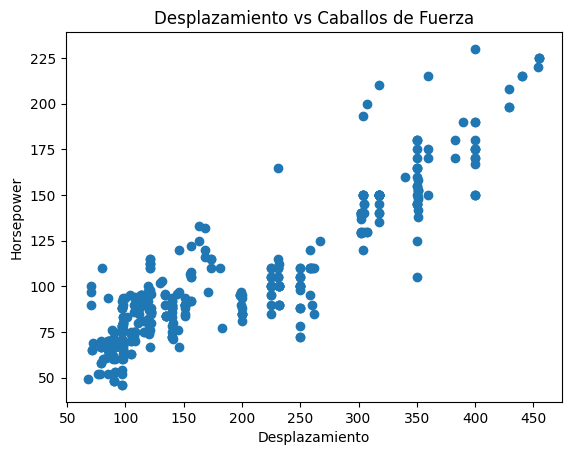

In [7]:
plt.figure()
plt.scatter(df['displacement'], df['horsepower'])
plt.title("Desplazamiento vs Caballos de Fuerza")
plt.xlabel("Desplazamiento")
plt.ylabel("Horsepower")
plt.show()

Gráfico de barras (mpg por origen)

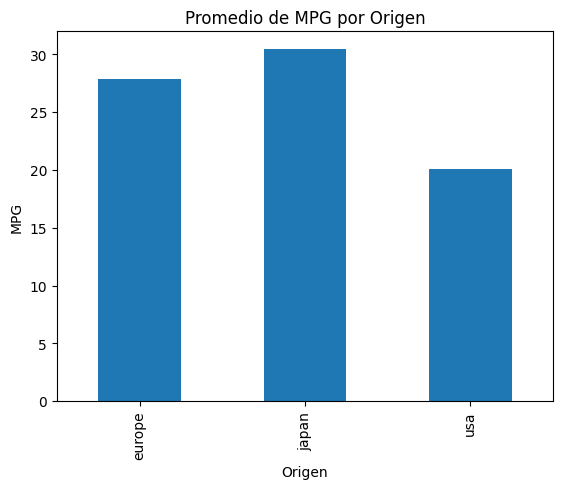

In [8]:
# Agrupar por origen
promedio = df.groupby('origin')['mpg'].mean()

# Graficar
plt.figure()
promedio.plot(kind='bar')
plt.title("Promedio de MPG por Origen")
plt.xlabel("Origen")
plt.ylabel("MPG")
plt.show()